# Stage 5: Tree models

This notebook compares a simple floor, decision trees, and a random forest using the shared preprocessing pipeline. Cross-validation is performed on the training split only.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    repo_root = Path("/Users/leshakamadara/bank-LM-prediction")
sys.path.insert(0, str(repo_root))

from src.data import get_split
from src.evaluate import cv_report, save_result
from src.pipeline import build

X_train, X_test, y_train, y_test = get_split()
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (36168, 15)
Test shape: (9043, 15)


## 1. DummyClassifier floor

In [2]:
dummy = build(DummyClassifier(strategy="prior"))
dummy_result = cv_report("Dummy prior", dummy, X_train, y_train)
save_result(dummy_result, repo_root / "reports" / "model_comparison.csv")
pd.DataFrame([dummy_result])

/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/leshakamadara/bank-LM-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

,name,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,train_pr_auc_mean,train_pr_auc_std,fit_time_mean
0,Dummy prior,0.116982,0.000053,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.116982,0.000013,0.043974


## Decision and reason

The prior dummy is the floor: it always uses the training class distribution and has no useful feature learning. A real model should improve PR-AUC over this baseline.

## 2. Decision tree comparison

In [3]:
tree_models = {
    "Decision tree gini": DecisionTreeClassifier(criterion="gini", class_weight="balanced", random_state=42),
    "Decision tree entropy": DecisionTreeClassifier(criterion="entropy", class_weight="balanced", random_state=42),
    "Decision tree depth 6 leaf 50": DecisionTreeClassifier(criterion="gini", max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=42),
}

tree_results = []
tree_pipelines = {}
for name, estimator in tree_models.items():
    pipeline = build(estimator)
    result = cv_report(name, pipeline, X_train, y_train)
    save_result(result, repo_root / "reports" / "model_comparison.csv")
    tree_results.append(result)
    tree_pipelines[name] = pipeline

pd.DataFrame(tree_results)[["name", "pr_auc_mean", "pr_auc_std", "train_pr_auc_mean", "roc_auc_mean", "f1_mean", "precision_mean", "recall_mean"]]

,name,pr_auc_mean,pr_auc_std,train_pr_auc_mean,roc_auc_mean,f1_mean,precision_mean,recall_mean
0,Decision tree gini,0.176376,0.007513,1.000000,0.608932,0.308913,0.307673,0.310328
1,Decision tree entropy,0.175388,0.007725,1.000000,0.609096,0.308134,0.301806,0.314819
2,Decision tree depth 6 leaf 50,0.347166,0.007796,0.365758,0.749013,0.392258,0.300969,0.566303


## Decision and reason

All decision trees use `class_weight="balanced"` because the positive class is rare. The unlimited-depth trees show how a flexible tree behaves, while `max_depth=6` and `min_samples_leaf=50` provide a simpler regularized comparison.

## 3. Random forest

In [4]:
forest_estimator = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
forest_pipeline = build(forest_estimator)
forest_result = cv_report("Random forest", forest_pipeline, X_train, y_train)
report_path = repo_root / "reports" / "model_comparison.csv"
save_result(forest_result, report_path)
forest_pipeline.fit(X_train, y_train)

if report_path.exists() and report_path.stat().st_size > 0:
    all_results = pd.read_csv(report_path)
else:
    all_results = pd.DataFrame([forest_result])
display(all_results.sort_values("pr_auc_mean", ascending=False))

,name,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,train_pr_auc_mean,train_pr_auc_std,fit_time_mean
3,HistGradientBoosting-tuned,0.448903,0.011179,0.797768,0.000896,0.446291,0.007269,0.347402,0.010083,0.624439,0.007023,0.519569,0.006918,1.357185
0,HistGradientBoosting,0.440183,0.009540,0.795136,0.002760,0.445864,0.009918,0.350782,0.012016,0.612151,0.006734,0.522408,0.009359,7.849121
2,Random forest-tuned,0.437522,0.013917,0.787832,0.003876,0.453371,0.004225,0.371698,0.007046,0.581422,0.010245,0.700831,0.003898,46.363106
10,Random forest,0.411338,0.015292,0.776984,0.004182,0.424500,0.020910,0.476966,0.016705,0.382652,0.024176,1.000000,0.000000,1.300103
1,Decision tree-tuned,0.402857,0.013289,0.756731,0.008299,0.360107,0.005740,0.246054,0.004716,0.671713,0.017116,0.490113,0.001235,0.464361
5,KNeighbors-tuned,0.388705,0.010675,0.754646,0.001279,0.237650,0.011928,0.671733,0.030047,0.144409,0.007865,1.000000,0.000000,0.054827
9,Decision tree depth 6 leaf 50,0.347166,0.007796,0.749013,0.002266,0.392258,0.008481,0.300969,0.015612,0.566303,0.025456,0.365758,0.002196,0.128575
4,KNeighbors,0.335516,0.011747,0.729144,0.005470,0.256434,0.011336,0.607519,0.029026,0.162609,0.007966,0.451202,0.002987,0.063838
7,Decision tree gini,0.176376,0.007513,0.608932,0.009150,0.308913,0.015589,0.307673,0.013535,0.310328,0.018693,1.000000,0.000000,0.243158
8,Decision tree entropy,0.175388,0.007725,0.609096,0.008593,0.308134,0.015314,0.301806,0.017359,0.314819,0.013549,1.000000,0.000000,0.262040


## Decision and reason

A forest averages many randomized trees. This reduces the variance of any one tree, so it usually generalizes better than a single unlimited-depth tree.

## 4. Train versus cross-validation PR-AUC

In [5]:
comparison = all_results[["name", "train_pr_auc_mean", "pr_auc_mean", "pr_auc_std"]].copy()
comparison = comparison.rename(columns={"train_pr_auc_mean": "Train PR-AUC", "pr_auc_mean": "CV PR-AUC", "pr_auc_std": "CV PR-AUC std"})
display(comparison.sort_values("CV PR-AUC", ascending=False))

,name,Train PR-AUC,CV PR-AUC,CV PR-AUC std
3,HistGradientBoosting-tuned,0.519569,0.448903,0.011179
0,HistGradientBoosting,0.522408,0.440183,0.009540
2,Random forest-tuned,0.700831,0.437522,0.013917
10,Random forest,1.000000,0.411338,0.015292
1,Decision tree-tuned,0.490113,0.402857,0.013289
5,KNeighbors-tuned,1.000000,0.388705,0.010675
9,Decision tree depth 6 leaf 50,0.365758,0.347166,0.007796
4,KNeighbors,0.451202,0.335516,0.011747
7,Decision tree gini,1.000000,0.176376,0.007513
8,Decision tree entropy,1.000000,0.175388,0.007725


## Overfitting explanation

A large gap between train PR-AUC and CV PR-AUC means the model fits the training folds much better than unseen validation folds. Unlimited-depth trees can memorize small groups, so their gap is a useful warning. Depth and leaf-size limits reduce this variance; a forest reduces it by averaging many varied trees.

## 5. Gini impurity by hand

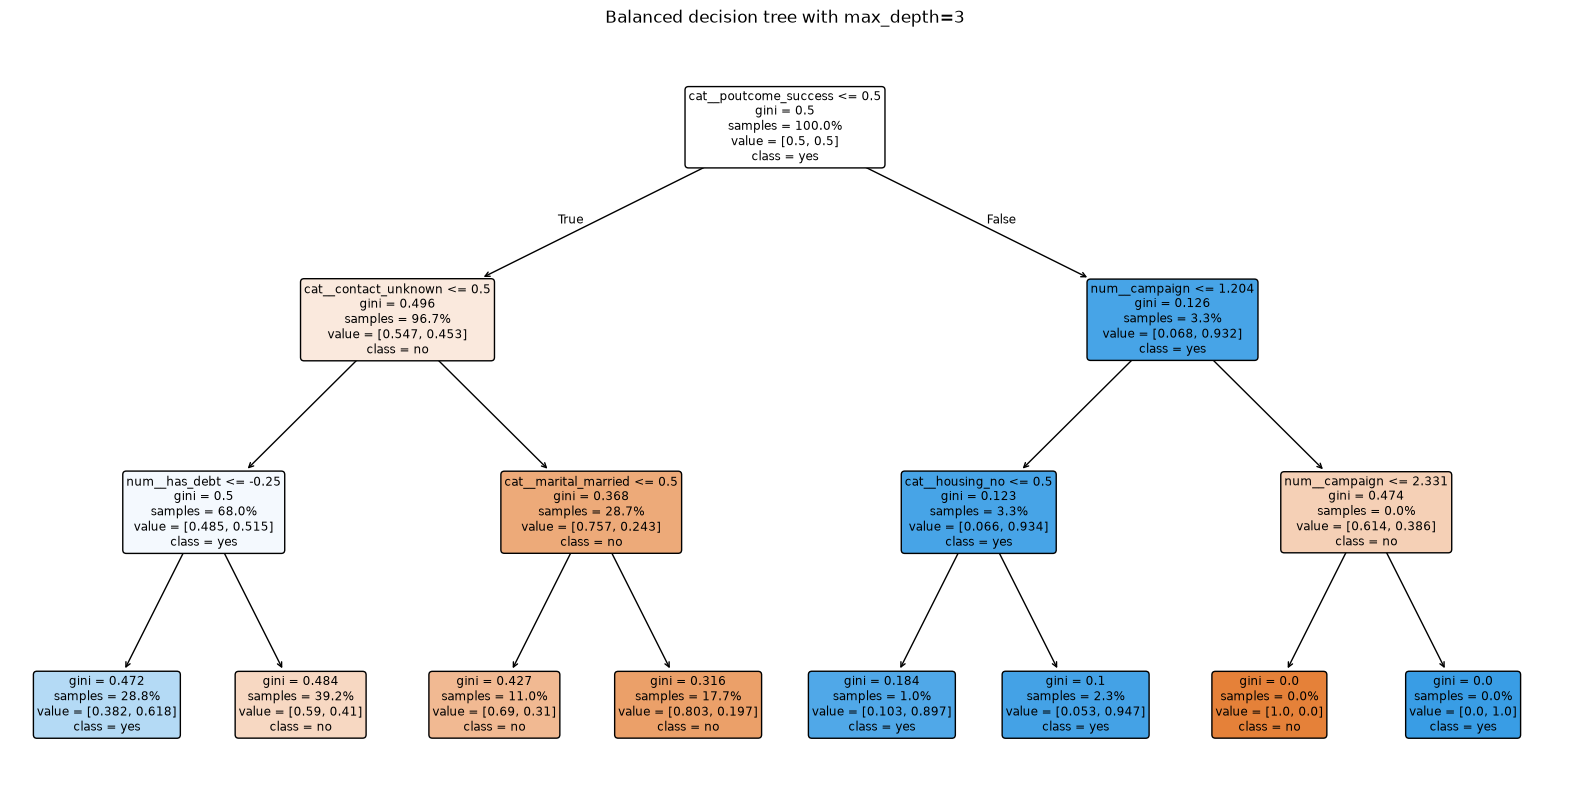

Root Gini by hand: 0.206594
Root Gini in tree_: 0.206594
Weighted child Gini: 0.187269
Impurity decrease: 0.019325
Tree impurity decrease: 0.019325


In [6]:
depth_three_tree = build(DecisionTreeClassifier(criterion="gini", max_depth=3, class_weight="balanced", random_state=42))
depth_three_tree.fit(X_train, y_train)
depth_three_features = depth_three_tree.named_steps["prep"].get_feature_names_out()
depth_three_model = depth_three_tree.named_steps["model"]

plt.figure(figsize=(20, 10))
plot_tree(
    depth_three_model,
    feature_names=depth_three_features,
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    proportion=True,
)
plt.title("Balanced decision tree with max_depth=3")
plt.show()

simple_tree = build(DecisionTreeClassifier(criterion="gini", max_depth=1, class_weight=None, random_state=42))
simple_tree.fit(X_train, y_train)
prep = simple_tree.named_steps["prep"]
features = simple_tree.named_steps["features"].transform(X_train)
transformed_train = prep.transform(features)
tree = simple_tree.named_steps["model"].tree_

p_yes = y_train.mean()
p_no = 1 - p_yes
root_gini_by_hand = 1 - p_yes**2 - p_no**2
print(f"Root Gini by hand: {root_gini_by_hand:.6f}")
print(f"Root Gini in tree_: {tree.impurity[0]:.6f}")
assert abs(root_gini_by_hand - tree.impurity[0]) < 1e-12

root_feature = tree.feature[0]
root_threshold = tree.threshold[0]
left_rows = transformed_train[:, root_feature] <= root_threshold
right_rows = ~left_rows

def gini(labels):
    yes_rate = labels.mean()
    return 1 - yes_rate**2 - (1 - yes_rate)**2

left_gini = gini(y_train[left_rows])
right_gini = gini(y_train[right_rows])
left_weight = left_rows.mean()
right_weight = right_rows.mean()
weighted_child_gini = left_weight * left_gini + right_weight * right_gini
impurity_decrease = root_gini_by_hand - weighted_child_gini
print(f"Weighted child Gini: {weighted_child_gini:.6f}")
print(f"Impurity decrease: {impurity_decrease:.6f}")
print(f"Tree impurity decrease: {tree.impurity[0] - (tree.weighted_n_node_samples[1] / tree.weighted_n_node_samples[0]) * tree.impurity[1] - (tree.weighted_n_node_samples[2] / tree.weighted_n_node_samples[0]) * tree.impurity[2]:.6f}")

## Decision and reason

Gini measures how mixed the two classes are in a node. The impurity decrease is the parent impurity minus the weighted child impurity, so a useful split makes the child nodes more class-pure.

## 6. Gini versus entropy

Gini and entropy both reward splits that separate the positive and negative classes. Their formulas differ, but they often rank candidate splits similarly, so the resulting trees can look alike. The random forest usually beats one tree because averaging many decorrelated trees lowers variance and makes predictions less dependent on one sequence of greedy splits.

## 7. Random forest feature importances

,feature,importance
8,num__balance_log,0.112074
1,num__balance,0.111398
2,num__day,0.097122
0,num__age,0.095774
3,num__campaign,0.055942
51,cat__poutcome_success,0.032987
4,num__pdays,0.032466
36,cat__contact_unknown,0.024398
7,num__has_debt,0.018953
5,num__previous,0.018188


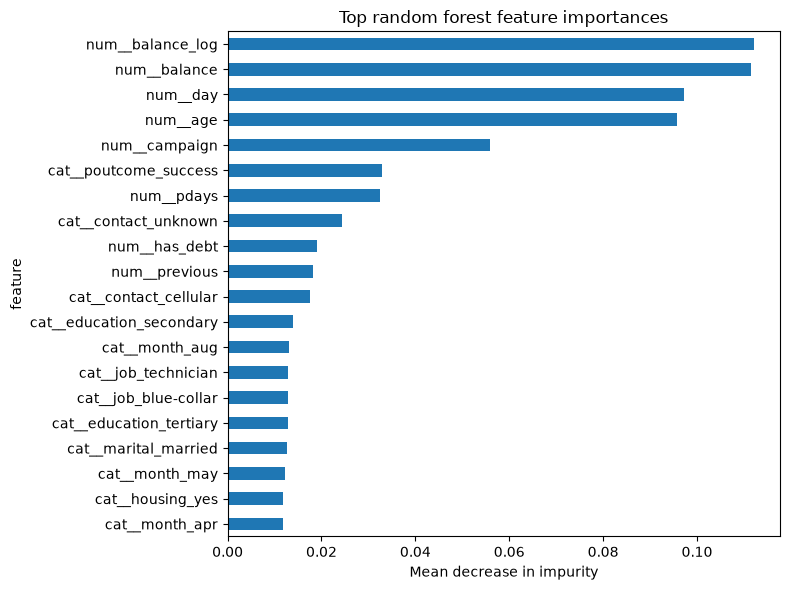

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    repo_root = Path("/Users/leshakamadara/bank-LM-prediction")
sys.path.insert(0, str(repo_root))

if "X_train" not in globals() or "y_train" not in globals():
    from src.data import get_split

    X_train, _, y_train, _ = get_split()
if "build" not in globals():
    from src.pipeline import build

if "forest_pipeline" not in globals() or not hasattr(
    forest_pipeline.named_steps["model"], "feature_importances_"
):
    forest_pipeline = build(
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        )
    )
    forest_pipeline.fit(X_train, y_train)

feature_names = forest_pipeline.named_steps["prep"].get_feature_names_out()
importances = forest_pipeline.named_steps["model"].feature_importances_
importance_table = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_table = importance_table.sort_values("importance", ascending=False)
display(importance_table.head(20))

importance_table.head(20).sort_values("importance").plot.barh(
    x="feature", y="importance", legend=False, figsize=(8, 6)
)
plt.title("Top random forest feature importances")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## Decision and reason

The importance names come from the fitted `prep` step, so one-hot category names remain connected to their original variables. These values describe how much the forest used each feature to reduce impurity; they are useful for interpretation but are not causal effects.